In [1]:
# %pip install numpy matplotlib
import math
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


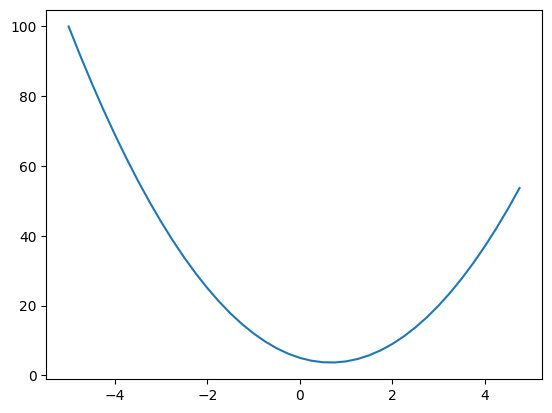

In [4]:
xs = np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
print(ys)
plt.plot(xs, ys)

In [5]:
h = 0.001
x = 3.0
print(f(x + h)) # look at the graph, increasing x by h increases f(x) as we move right from x=3.0 on the x axis and the curve goes up
print(f(x - h)) # look at the graph, decreasing x by h decreases f(x) as we move left from x=3.0 on the x axis and the curve goes down

20.014003000000002
19.986003000000004


In [6]:
# Numerical approximation of the derivative at x=3.0
h = [  0.1, 0.01, 0.001, 0.0001, 0.00001]
x = 3.0
for delta in h:
    print("h:", delta, "approximate derivative:",  (f(x + delta) - f(x)) / delta)
# As h gets smaller, the approximate derivative approaches 14, which is the exact derivative of f(x) at x=3.0

h: 0.1 approximate derivative: 14.300000000000068
h: 0.01 approximate derivative: 14.029999999999632
h: 0.001 approximate derivative: 14.00300000000243
h: 0.0001 approximate derivative: 14.000300000063248
h: 1e-05 approximate derivative: 14.00003000000538


In [7]:
# Numerical approximation of the derivative at x=3.0
h = [  0.1, 0.01, 0.001, 0.0001, 0.00001]
x = -3.0
print(f(x))
for delta in h:
    print("h:", delta, "approximate derivative:",  (f(x + delta) - f(x)) / delta)
# As h gets smaller, the approximate derivative approaches -22, which is the exact derivative of f(x) at x=-3.0

44.0
h: 0.1 approximate derivative: -21.700000000000017
h: 0.01 approximate derivative: -21.9699999999996
h: 0.001 approximate derivative: -21.996999999998934
h: 0.0001 approximate derivative: -21.999700000066014
h: 1e-05 approximate derivative: -21.999970000052823


In [8]:
#getting more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [9]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
a+=h
d2 = a * b + c
print( 'd1:', d1 )
print( 'd2:', d2 )
print( 'slope:', (d2 - d1) / h )  # approximate derivative of d with respect to a

d1: 4.0
d2: 3.999699999999999
slope: -3.000000000010772


In [10]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
b+=h
d2 = a * b + c
print( 'd1:', d1 )
print( 'd2:', d2 )
print( 'slope:', (d2 - d1) / h )  # approximate derivative of d with respect to b

d1: 4.0
d2: 4.0002
slope: 2.0000000000042206


In [11]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
c+=h
d2 = a * b + c
print( 'd1:', d1 )
print( 'd2:', d2 )
print( 'slope:', (d2 - d1) / h )  # approximate derivative of d with respect to a

d1: 4.0
d2: 4.0001
slope: 0.9999999999976694


In [12]:
# A simple class to represent a value and operations on it

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None  # function to compute the gradient
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0* out.grad
            other.grad += 1.0* out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):  # other * self
        return self * other
    
    def __truediv__(self, other):  # self / other
        return self * other**-1

    def __neg__(self):  # -self
        return self * -1
    def __sub__(self, other):  # self - other
        return self + (-other)
    def __pow__(self, other):  # self ** other
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other -1)) * out.grad
        out._backward = _backward
        return out
    

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        n = self.data
        out = Value(math.exp(n), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    



In [13]:
from graphviz import Digraph

def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='png', graph_attr={'rankdir': 'LR'})  # left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid+n._op, label = n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    
    return dot

In [14]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')  #
#x = x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label='x1*w1'
x2w2 = x2 * w2
x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 + b
n.label='n'
o = n.tanh()
o.label='o'
o.backward()


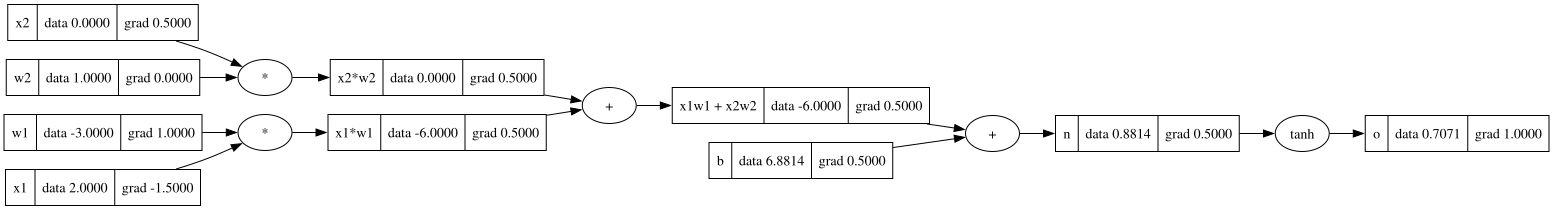

In [15]:
draw_dot(o)

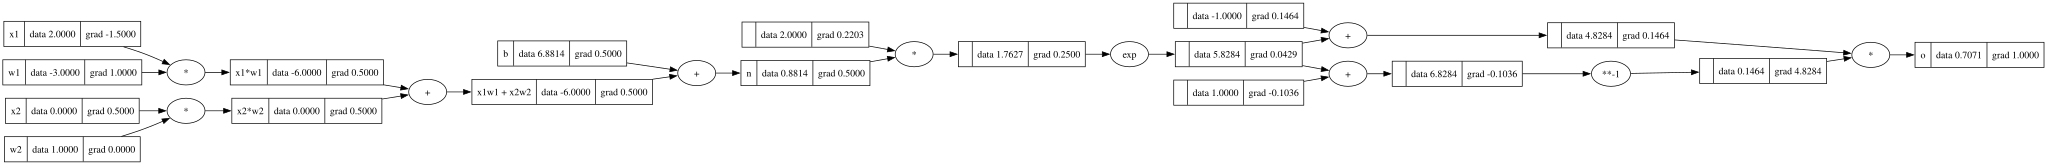

In [16]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')  #
#x = x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label='x1*w1'
x2w2 = x2 * w2
x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 + b
n.label='n'

e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label='o'
o.backward()
draw_dot(o) 

In [17]:
import torch
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)  
b = torch.tensor(6.8813735870195432, requires_grad=True)
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()
print(x1.grad.item())
print(x2.grad.item())
print(w1.grad.item())
print(w2.grad.item())
print(b.grad.item())

0.7071067094802856
-1.5000003576278687
0.5000001192092896
1.000000238418579
0.0
0.5000001192092896


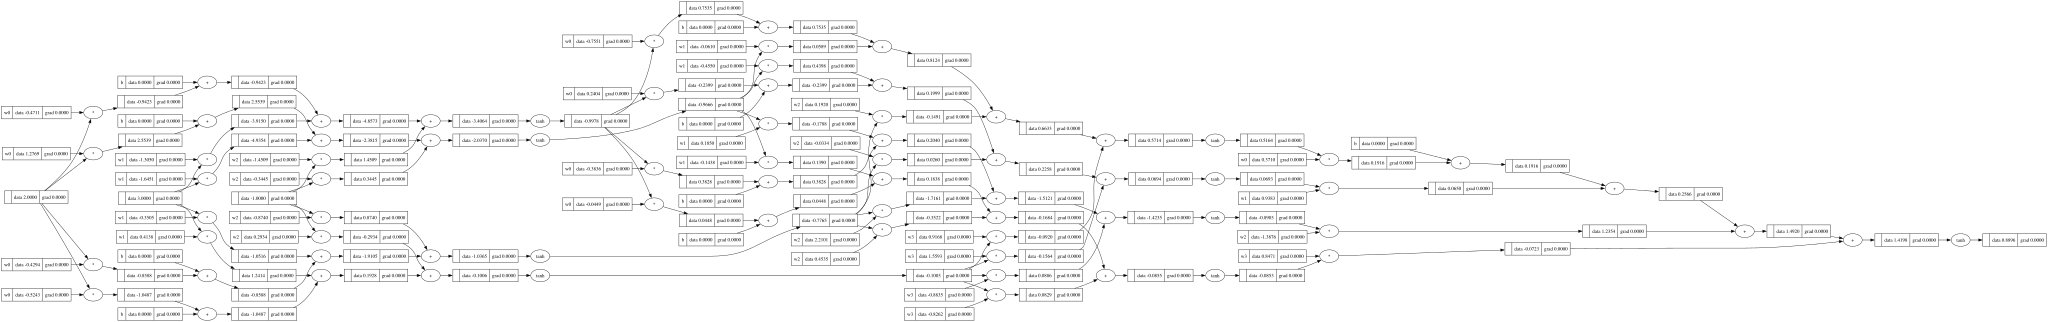

In [18]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.randn(), label=f'w{i}') for i in range(nin)]
        self.b = Value(0.0, label='b')

    def __call__(self, x):
        # Weighted sum plus bias
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x if len(x) > 1 else x[0]
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
x = [Value(2.0), Value(3.0), Value(-1.0)]  # example input
n = MLP(3, [4,4,1])
out = n(x)
draw_dot(out)

In [ ]:
xs = [[Value(2.0), Value(3.0), Value(-1.0)],
       [Value(3.0), Value(-1.0), Value(0.5)],
       [Value(0.5), Value(1.0), Value(1.0)],
         [Value(1.0), Value(1.0), Value(-1.0)]]
ys = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)]  # example target output

# Forward pass to get predictions
ypred = [n(x) for x in xs]
print(ypred)

[Value(data=0.9375124059976248), Value(data=-0.8260069516574718), Value(data=0.9324206502222828), Value(data=0.9073103688292845)]


In [ ]:
# Calculate loss (mean squared error)
loss = sum(((yout - ygt)**2 for yout, ygt in zip(ypred, ys)), Value(0.0))
loss.label='loss'
print(loss)

Value(data=3.7770192174078043)


In [ ]:
# Backward pass to compute gradients
loss.backward()

In [ ]:
# Update parameters using gradient descent
for p in n.parameters():
    p.data += -0.01 * p.grad  # SGD update

In [54]:
xs = [[Value(2.0), Value(3.0), Value(-1.0)],
       [Value(3.0), Value(-1.0), Value(0.5)],
       [Value(0.5), Value(1.0), Value(1.0)],
         [Value(1.0), Value(1.0), Value(-1.0)]]
ys = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)]  # example target output

# Putting it together
for k in range(20):  # 20 epochs
    # Forward pass to get predictions
    ypred = [n(x) for x in xs]

    # Calculate loss (mean squared error)
    loss = sum(((yout - ygt)**2 for yout, ygt in zip(ypred, ys)), Value(0.0))
    loss.label='loss'
    print(f"Epoch {k}: loss {loss.data}")

    # Backward pass to compute gradients
    loss.backward()

    # Update parameters using gradient descent
    for p in n.parameters():
        p.data += -0.01 * p.grad  # SGD update

    # Zero gradients
    for p in n.parameters():
        p.grad = 0.0

Epoch 0: loss 3.705080356481341
Epoch 1: loss 3.624703196814702
Epoch 2: loss 3.602831011698104
Epoch 3: loss 3.578829756807096
Epoch 4: loss 3.5524438598471533
Epoch 5: loss 3.5233912610467235
Epoch 6: loss 3.491365504517711
Epoch 7: loss 3.4560413362923907
Epoch 8: loss 3.4170857390059837
Epoch 9: loss 3.374177001530303
Epoch 10: loss 3.327035043371596
Epoch 11: loss 3.275466442725519
Epoch 12: loss 3.2194267745377276
Epoch 13: loss 3.1590998459561392
Epoch 14: loss 3.0949868422537703
Epoch 15: loss 3.027987407032388
Epoch 16: loss 2.959440796037363
Epoch 17: loss 2.8910849638117124
Epoch 18: loss 2.8248970748860405
Epoch 19: loss 2.7628126858284303
